# Embedding Space Analysis
UMAP projections of synthetic (500K) vs real (70K) embeddings

In [1]:
import numpy as np
import pandas as pd
import umap
import matplotlib.pyplot as plt

DATA_DIR = "../data"

# Load embeddings
synth_embs = np.load(f"{DATA_DIR}/embeddings_synthetic_500k.npy")
real_embs  = np.load(f"{DATA_DIR}/embeddings_base_70k.npy")

# Load labels
synth_df = pd.read_csv(f"{DATA_DIR}/synthetic_500k.csv")
synth_labels = synth_df["stars"].values.astype(float)

real_df = pd.read_json(f"{DATA_DIR}/restaurant_train_70k.json", lines=True)
real_labels = real_df["stars"].values.astype(float)

print(f"Synthetic embeddings: {synth_embs.shape}")
print(f"Real embeddings:      {real_embs.shape}")
print(f"Synthetic labels:     {synth_labels.shape} | unique: {np.unique(synth_labels)}")
print(f"Real labels:          {real_labels.shape} | unique: {np.unique(real_labels)}")

/Users/iy2159/Code/beacon_yelp/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Synthetic embeddings: (500000, 384)
Real embeddings:      (70000, 384)
Synthetic labels:     (500000,) | unique: [1. 2. 3. 4. 5.]
Real labels:          (70000,) | unique: [1. 2. 3. 4. 5.]


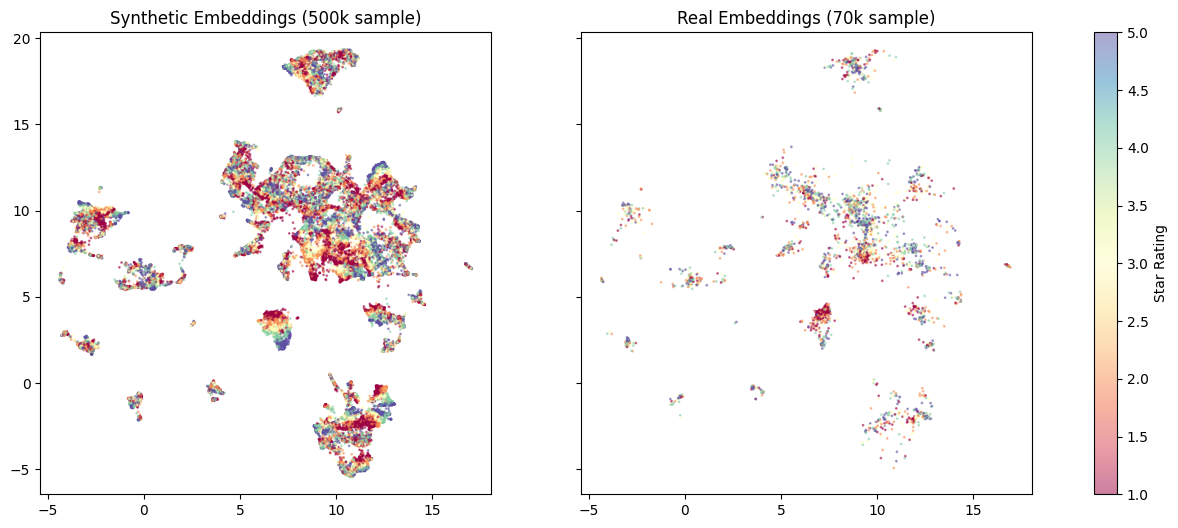

In [4]:
from sklearn.preprocessing import StandardScaler

# 1. Sampling for efficiency (UMAP on 500k+ points is slow)
# Adjust n_sample based on your RAM; 10k-20k is usually plenty for visualization
n_sample_synth = 50000 
n_sample_real = 3000

idx_synth = np.random.choice(len(synth_embs), n_sample_synth, replace=False)
idx_real = np.random.choice(len(real_embs), n_sample_real, replace=False)

s_embs_sub = synth_embs[idx_synth]
r_embs_sub = real_embs[idx_real]

# 2. Combine and Fit UMAP
# We fit on both to ensure they share the same coordinate system/manifold
combined_embs = np.vstack([s_embs_sub, r_embs_sub])
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine')
embedding_output = reducer.fit_transform(combined_embs)

# Split back for plotting
train_umap = embedding_output[:n_sample_synth]
real_umap = embedding_output[n_sample_synth:]

# 3. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

# Determine global axes limits for "Same Scale"
x_min, x_max = embedding_output[:, 0].min() - 1, embedding_output[:, 0].max() + 1
y_min, y_max = embedding_output[:, 1].min() - 1, embedding_output[:, 1].max() + 1

# Synthetic Plot
sc1 = ax1.scatter(train_umap[:, 0], train_umap[:, 1], c=synth_labels[idx_synth], 
                  cmap='Spectral', s=1, alpha=0.5)
ax1.set_title("Synthetic Embeddings (500k sample)")
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)

# Real Plot
sc2 = ax2.scatter(real_umap[:, 0], real_umap[:, 1], c=real_labels[idx_real], 
                  cmap='Spectral', s=1, alpha=0.5)
ax2.set_title("Real Embeddings (70k sample)")

# Add colorbar
cbar = fig.colorbar(sc2, ax=[ax1, ax2], label='Star Rating')
plt.show()